In [ ]:
!pip install -q opencv-python-headless tensorflow keras numpy matplotlib scikit-learn deepface face-recognition streamlit

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{\r\n  "username": "harshich05",\r\n  "key": "KGAT_15b21e3036ff3116a9097876d4be7c92"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset
!unzip -o face-mask-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/with_mask/with_mask_3297.jpg  
  inflating: data/with_mask/with_mask_3298.jpg  
  inflating: data/with_mask/with_mask_3299.jpg  
  inflating: data/with_mask/with_mask_33.jpg  
  inflating: data/with_mask/with_mask_330.jpg  
  inflating: data/with_mask/with_mask_3300.jpg  
  inflating: data/with_mask/with_mask_3301.jpg  
  inflating: data/with_mask/with_mask_3302.jpg  
  inflating: data/with_mask/with_mask_3303.jpg  
  inflating: data/with_mask/with_mask_3304.jpg  
  inflating: data/with_mask/with_mask_3305.jpg  
  inflating: data/with_mask/with_mask_3306.jpg  
  inflating: data/with_mask/with_mask_3307.jpg  
  inflating: data/with_mask/with_mask_3308.jpg  
  inflating: data/with_mask/with_mask_3309.jpg  
  inflating: data/with_mask/with_mask_331.jpg  
  inflating: data/with_mask/with_mask_3310.jpg  
  inflating: data/with_mask/with_mask_3311.jpg  
  inflating: data/with_mask/with_mask_3312.jpg  
  inflating: data/with

In [ ]:
DATASET_PATH = "/content/data"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(DATASET_PATH, target_size=(224,224),
                                    batch_size=32, class_mode='categorical', subset='training')

val = datagen.flow_from_directory(DATASET_PATH, target_size=(224,224),
                                  batch_size=32, class_mode='categorical', subset='validation')

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import load_model

mask_model = load_model("/content/mask_model.h5")

In [ ]:
model.fit(train, validation_data=val, epochs=3)
model.save("/content/mask_model.h5")

Epoch 1/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9983 - loss: 0.0222 - val_accuracy: 0.9874 - val_loss: 0.0774
Epoch 2/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9993 - loss: 0.0158 - val_accuracy: 0.9868 - val_loss: 0.0727
Epoch 3/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.9998 - loss: 3.9657e-04 - val_accuracy: 0.9887 - val_loss: 0.0886


In [ ]:
!rm -rf /root/.deepface/weights

In [ ]:
!pip install deepface

In [ ]:
!mkdir -p /root/.deepface/weights

In [ ]:
from deepface import DeepFace

In [ ]:
import cv2

# Load image (fix path if needed)
img = cv2.imread('/content/data/with_mask/with_mask_1.jpg')

# Check image
if img is None:
    print("❌ Image not found")
else:
    result = DeepFace.analyze(img, actions=['emotion'], enforce_detection=False)
    print(result[0]['dominant_emotion'])

angry


In [ ]:
import os
os.makedirs("/content/hospital_staff", exist_ok=True)

In [ ]:
!pip install bing-image-downloader

In [ ]:
from bing_image_downloader import downloader

downloader.download("doctor face", limit=20, output_dir="/content", adult_filter_off=True)

[%] Downloading Images to /content/doctor face


[!!]Indexing page: 1

[%] Indexed 32 Images on Page 1.


[%] Downloading Image #1 from https://img.freepik.com/premium-photo/caucasian-doctor-with-stethoscope-face-mask_69593-8435.jpg?w=996
[%] File Downloaded !

[%] Downloading Image #2 from https://img.freepik.com/premium-psd/doctor-with-stethoscope-his-face_1026556-95956.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://www.shutterstock.com/shutterstock/photos/1693557730/display_1500/stock-photo-caucasian-doctor-with-stethoscope-and-face-mask-portrait-on-a-white-background-1693557730.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://img.freepik.com/premium-photo/doctor-with-glasses-stethoscope-his-face_1062240-440.jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://img.freepik.com/premium-photo/doctor-medical-professional-wearing-stethoscope-his-face_971713-14302.jpg
[%] File Downloaded !

[%] Downloading Image #6 from https://img.freepik.com

In [ ]:
!ls /content

 app.py			     face-mask-dataset.zip   logs.txt
 cloudflared-linux-amd64     final_output.jpg	     mask_model.h5
 cloudflared-linux-amd64.1   hospital_staff	     sample_data
 data			    'kaggle (1).json'
'doctor face'		     kaggle.json


In [ ]:
!ls "/content/doctor face"

Image_10.jpg  Image_14.jpg  Image_18.jpg  Image_2.jpg  Image_6.jpg
Image_11.jpg  Image_15.jpg  Image_19.jpg  Image_3.jpg  Image_7.jpg
Image_12.jpg  Image_16.jpg  Image_1.jpg   Image_4.jpg  Image_8.jpg
Image_13.jpg  Image_17.jpg  Image_20.jpg  Image_5.jpg  Image_9.jpg


In [ ]:
import shutil
import os

source = "/content/doctor face"

for file in os.listdir(source):
    shutil.move(os.path.join(source, file), "/content/hospital_staff/" + file)

print("Images moved successfully ✅")

Images moved successfully ✅


In [ ]:
!ls /content/hospital_staff

Image_10.jpg  Image_14.jpg  Image_18.jpg  Image_2.jpg  Image_6.jpg
Image_11.jpg  Image_15.jpg  Image_19.jpg  Image_3.jpg  Image_7.jpg
Image_12.jpg  Image_16.jpg  Image_1.jpg   Image_4.jpg  Image_8.jpg
Image_13.jpg  Image_17.jpg  Image_20.jpg  Image_5.jpg  Image_9.jpg


In [ ]:
import face_recognition
import os

known_encodings = []

dataset_path = "/content/hospital_staff"

for img_name in os.listdir(dataset_path):
    path = os.path.join(dataset_path, img_name)

    image = face_recognition.load_image_file(path)
    encodings = face_recognition.face_encodings(image)

    if len(encodings) > 0:
        known_encodings.append(encodings[0])

print("Encodings created ✅")
print("Total faces stored:", len(known_encodings))

Encodings created ✅
Total faces stored: 12


In [ ]:
def verify_person(test_img):
    enc = face_recognition.face_encodings(test_img)

    if len(enc) == 0:
        return "No Face"

    matches = face_recognition.compare_faces(known_encodings, enc[0])

    if True in matches:
        return "Hospital Staff ✅"
    else:
        return "Unknown ❌"

In [ ]:
!ls /content/hospital_staff

Image_10.jpg  Image_14.jpg  Image_18.jpg  Image_2.jpg  Image_6.jpg
Image_11.jpg  Image_15.jpg  Image_19.jpg  Image_3.jpg  Image_7.jpg
Image_12.jpg  Image_16.jpg  Image_1.jpg   Image_4.jpg  Image_8.jpg
Image_13.jpg  Image_17.jpg  Image_20.jpg  Image_5.jpg  Image_9.jpg


In [ ]:
import os
import face_recognition

files = os.listdir("/content/hospital_staff")

# pick first image automatically
test_path = "/content/hospital_staff/" + files[0]

print("Testing image:", test_path)

test_img = face_recognition.load_image_file(test_path)

print(verify_person(test_img))

Testing image: /content/hospital_staff/Image_16.jpg
Hospital Staff ✅


Staff encodings loaded ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Results: [('No Mask ❌', 'neutral', 'Unknown ❌', 0.7)]


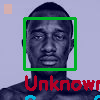

True

In [ ]:
# ================== IMPORTS ==================
import cv2
import numpy as np
import os
import face_recognition
from deepface import DeepFace
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow

# ================== LOAD MODEL ==================
mask_model = load_model("/content/mask_model.h5")

# ================== FACE DETECTOR ==================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# ================== LOAD STAFF ENCODINGS ==================
known_encodings = []

dataset_path = "/content/hospital_staff"

for img_name in os.listdir(dataset_path):
    path = os.path.join(dataset_path, img_name)
    img = face_recognition.load_image_file(path)
    enc = face_recognition.face_encodings(img)

    if len(enc) > 0:
        known_encodings.append(enc[0])

print("Staff encodings loaded ✅")

# ================== HEATMAP ==================
heatmap = np.zeros((480, 640))

def update_heatmap(faces):
    global heatmap
    for (x,y,w,h) in faces:
        heatmap[y:y+h, x:x+w] += 1

# ================== SCORE ==================
def compute_score(mask, emotion, identity):
    m = 1 if "Mask" in mask else 0
    e = 0.5 if emotion == "angry" else 1
    i = 1 if "Staff" in identity else 0
    return round(0.5*m + 0.2*e + 0.3*i, 2)

# ================== MAIN FUNCTION ==================
def analyze(frame):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    results = []

    for (x,y,w,h) in faces:

        face = frame[y:y+h, x:x+w]

        # Skip very small faces (IMPORTANT FIX)
        if face.shape[0] < 50 or face.shape[1] < 50:
           continue

        # -------- MASK --------
        f = cv2.resize(face, (224,224))/255.0
        f = np.reshape(f, (1,224,224,3))
        pred = mask_model.predict(f)

        mask_label = "Mask 😷" if np.argmax(pred)==0 else "No Mask ❌"

        # -------- EMOTION --------
        try:
          emotion = DeepFace.analyze(face, actions=['emotion'], enforce_detection=False)[0]['dominant_emotion']
        except:
          emotion = "unknown"

        # -------- STAFF VERIFY --------
        try:
          face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
          face_locations = [(0, face_rgb.shape[1], face_rgb.shape[0], 0)]

          enc = face_recognition.face_encodings(face_rgb, face_locations)

          if len(enc) > 0:
             distances = face_recognition.face_distance(known_encodings, enc[0])
             identity = "Hospital Staff ✅" if np.min(distances) < 0.6 else "Unknown ❌"
          else:
             identity = "No Face"
        except:
             identity = "Error"

        # -------- SCORE --------
        score = compute_score(mask_label, emotion, identity)

        # -------- DRAW --------
        cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(frame, mask_label, (x,y-40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.putText(frame, emotion, (x,y-20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0),2)
        cv2.putText(frame, identity, (x,y+h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255),2)
        cv2.putText(frame, f"Score: {score}", (x,y+h+40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0),2)

        results.append((mask_label, emotion, identity, score))

    update_heatmap(faces)

    return frame, results

# ================== TEST ==================
img = cv2.imread("/content/data/without_mask/without_mask_1.jpg")

output_frame, results = analyze(img)

print("Results:", results)

# -------- HEATMAP OVERLAY --------
# Resize heatmap to match frame size
hm_resized = cv2.resize(heatmap, (output_frame.shape[1], output_frame.shape[0]))

# Normalize and convert
hm_normalized = cv2.normalize(hm_resized, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

# Apply colormap (convert to 3 channels)
hm_color = cv2.applyColorMap(hm_normalized, cv2.COLORMAP_JET)

# Overlay
overlay = cv2.addWeighted(output_frame, 0.7, hm_color, 0.3, 0)

cv2_imshow(overlay)
cv2.imwrite("/content/final_output.jpg", overlay)

In [ ]:
from google.colab import files
files.download("/content/final_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile app.py

Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import face_recognition
from deepface import DeepFace
from tensorflow.keras.models import load_model
import os

# Load model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

# Rebuild architecture
base = MobileNetV2(weights=None, include_top=False, input_shape=(224,224,3))

x = Flatten()(base.output)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

mask_model = Model(inputs=base.input, outputs=output)

# Load weights ONLY
mask_model.load_weights("/content/mask_model.h5")
# Load staff encodings
known_encodings = []
for img_name in os.listdir("/content/hospital_staff"):
    img = face_recognition.load_image_file("/content/hospital_staff/" + img_name)
    enc = face_recognition.face_encodings(img)
    if len(enc)>0:
        known_encodings.append(enc[0])

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades+'haarcascade_frontalface_default.xml'
)

# Score function
def compute_score(mask, emotion, identity):
    m = 1 if "Mask" in mask else 0
    e = 0.5 if emotion == "angry" else 1
    i = 1 if "Staff" in identity else 0
    return round(0.5*m + 0.2*e + 0.3*i, 2)

# UI
st.title("🏥 Hospital AI Monitoring Dashboard")

# ✅ USE UPLOAD INSTEAD OF CAMERA
img_file = st.file_uploader("Upload Image", type=["jpg","png"])

if img_file:
    file_bytes = np.asarray(bytearray(img_file.read()), dtype=np.uint8)
    frame = cv2.imdecode(file_bytes, 1)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,1.3,5)

    results = []   # ✅ VERY IMPORTANT

    for (x,y,w,h) in faces:
        face = frame[y:y+h, x:x+w]

        if face.shape[0] < 50:
            continue

        # MASK
        f = cv2.resize(face,(224,224))/255.0
        f = np.reshape(f,(1,224,224,3))
        mask = "Mask 😷" if np.argmax(mask_model.predict(f))==0 else "No Mask ❌"

        # EMOTION
        try:
            emotion = DeepFace.analyze(face, actions=['emotion'], enforce_detection=False)[0]['dominant_emotion']
        except:
            emotion = "unknown"

        # IDENTITY
        try:
            face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            loc = [(0, face_rgb.shape[1], face_rgb.shape[0], 0)]
            enc = face_recognition.face_encodings(face_rgb, loc)

            if len(enc)>0:
                dist = face_recognition.face_distance(known_encodings, enc[0])
                identity = "Hospital Staff ✅" if np.min(dist)<0.6 else "Unknown ❌"
            else:
                identity = "No Face"
        except:
            identity = "Error"

        # SCORE
        score = compute_score(mask, emotion, identity)

        # DRAW
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame, mask,(x,y-40),0,0.6,(0,255,0),2)
        cv2.putText(frame, emotion,(x,y-20),0,0.6,(255,0,0),2)
        cv2.putText(frame, identity,(x,y+h+20),0,0.6,(0,0,255),2)
        cv2.putText(frame, f"Score:{score}",(x,y+h+40),0,0.6,(255,255,0),2)

        # SAVE RESULT
        results.append((mask, emotion, identity, score))

    # SHOW IMAGE
    st.image(frame, channels="BGR")

    # SHOW RESULTS
    st.subheader("🔍 Detection Results")

    for (mask, emotion, identity, score) in results:
        st.success(f"😷 Mask: {mask}")
        st.info(f"😊 Emotion: {emotion}")
        st.warning(f"🧑 Identity: {identity}")
        st.write(f"📊 Score: {score}")

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!cat /content/logs.txt

In [ ]:
!pkill -f streamlit

get_ipython().system_raw(
    'streamlit run app.py --server.headless true --server.port 8501 &'
)

In [ ]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

--2026-04-01 07:11:58--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-01 07:11:58--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-01T07%3A52%3A41Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501

2026-04-01T07:12:06Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-01T07:12:06Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-01T07:12:11Z INF +--------------------------------------------------------------------------------------------+
2026-04-01T07:12:11Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-04-01T07:12:11Z INF |  https://identifies-arrived-britannica-arbitration.try